In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

In [5]:
CLEAN_PATH = "processed/floodsense_clean.csv"
PLOTS_DIR  = "eda_plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

In [6]:
DISTRICTS = ["Sindh_District", "Balochistan_District", "KP_District"]
DISTRICT_COLORS = {
    "Sindh_District":       "#E74C3C",
    "Balochistan_District": "#3498DB",
    "KP_District":          "#2ECC71",
}
 
def section(title):
    print("\n" + "=" * 75 + f"\n{title}\n" + "=" * 75)

In [7]:
df = pd.read_csv(CLEAN_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["district", "date"]).reset_index(drop=True)
print(f"Loaded: {df.shape}  |  Date range: {df['date'].min().date()} to {df['date'].max().date()}")

Loaded: (1365, 23)  |  Date range: 2022-01-01 to 2024-12-30



PHASE 1 — Temporal structure of floods


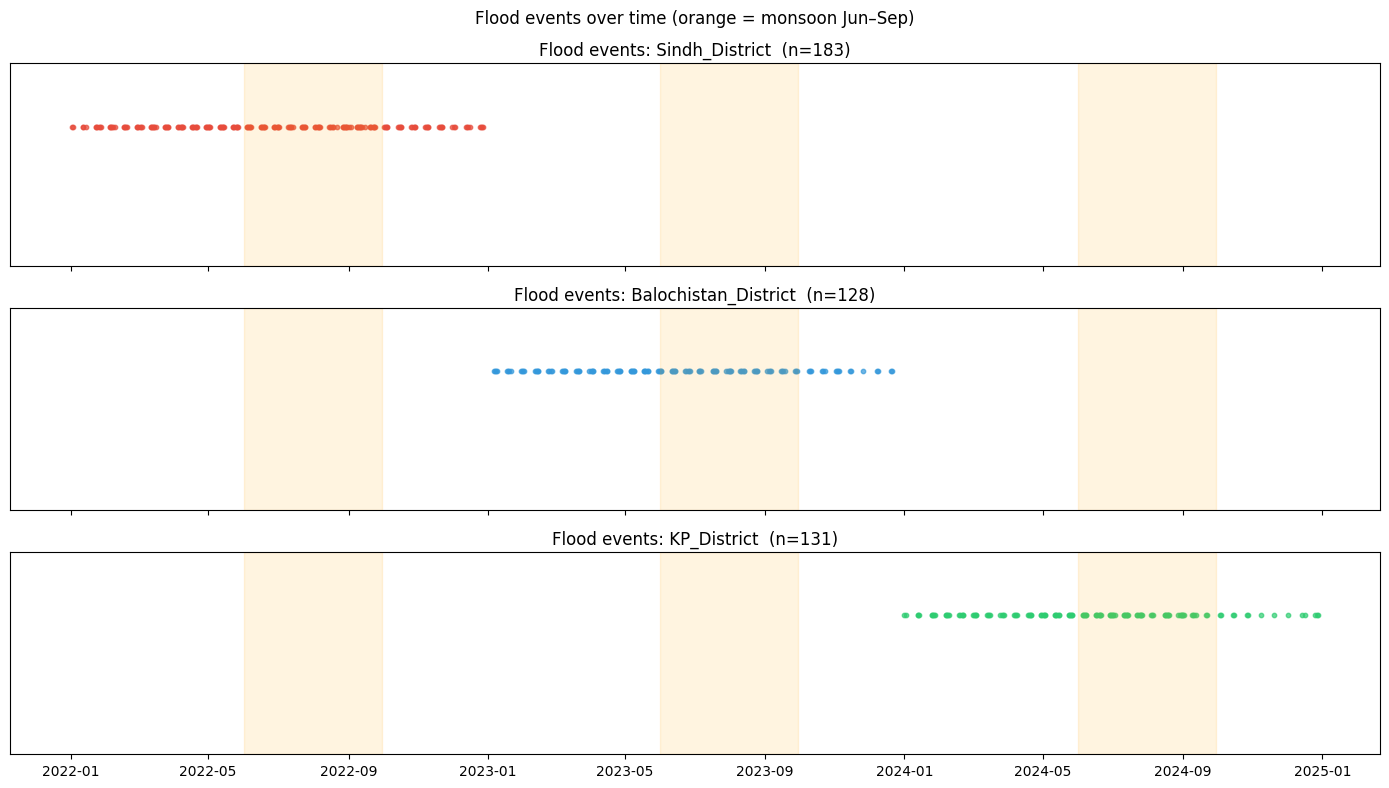

In [8]:
section("PHASE 1 — Temporal structure of floods")
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
for ax, district in zip(axes, DISTRICTS):
    sub = df[df["district"] == district].sort_values("date")
    flood_dates = sub.loc[sub["flood_event"] == 1, "date"]
    ax.scatter(flood_dates, [1] * len(flood_dates),
               color=DISTRICT_COLORS[district], s=10, alpha=0.7)
    ax.set_title(f"Flood events: {district}  (n={len(flood_dates)})")
    ax.set_ylim(-0.1, 1.5); ax.set_yticks([])
    for year in [2022, 2023, 2024]:
        ax.axvspan(pd.Timestamp(f"{year}-06-01"), pd.Timestamp(f"{year}-09-30"),
                   alpha=0.12, color="orange", label="Monsoon" if year == 2022 else None)
plt.suptitle("Flood events over time (orange = monsoon Jun–Sep)")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/01a_flood_timeseries.png", dpi=80)

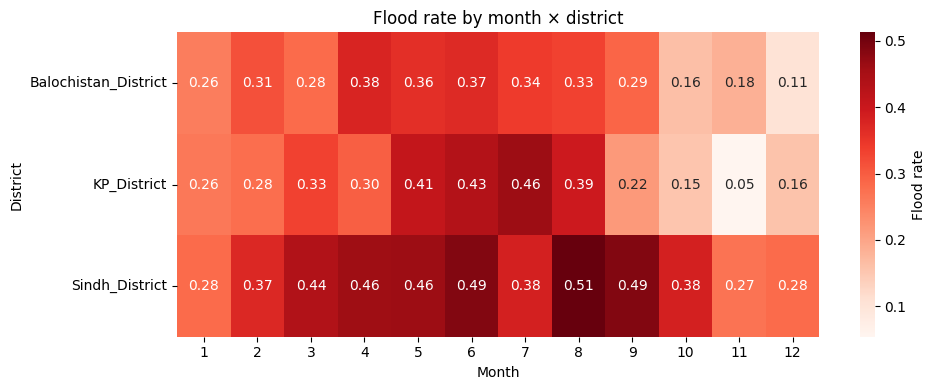

In [9]:
month_dist = df.groupby(["month", "district"])["flood_event"].mean().unstack()
plt.figure(figsize=(10, 4))
sns.heatmap(month_dist.T, annot=True, fmt=".2f", cmap="Reds",
            cbar_kws={"label": "Flood rate"})
plt.title("Flood rate by month × district")
plt.xlabel("Month"); plt.ylabel("District")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/01b_flood_rate_month_district.png", dpi=80)


In [10]:
year_dist = df.groupby(["year", "district"])["flood_event"].agg(["mean", "count"])
print("Flood rate by year × district:")
print(year_dist.round(3).to_string())
 
monsoon_rate = df[df["is_monsoon"] == 1]["flood_event"].mean()
nonmonsoon_rate = df[df["is_monsoon"] == 0]["flood_event"].mean()
print(f"\nMonsoon flood rate:     {monsoon_rate:.3f}")
print(f"Non-monsoon flood rate: {nonmonsoon_rate:.3f}")
print(f"Monsoon lift:           {monsoon_rate/nonmonsoon_rate:.2f}x")


Flood rate by year × district:
                            mean  count
year district                          
2022 Sindh_District        0.401    456
2023 Balochistan_District  0.281    455
2024 KP_District           0.289    454

Monsoon flood rate:     0.393
Non-monsoon flood rate: 0.289
Monsoon lift:           1.36x


In [16]:
df.query('district == "KP_District"')[["district", "year"]]

,district,year
455,KP_District,2024
456,KP_District,2024
457,KP_District,2024
458,KP_District,2024
459,KP_District,2024
...,...,...
904,KP_District,2024
905,KP_District,2024
906,KP_District,2024
907,KP_District,2024


In [19]:
section("PHASE 2 — Class balance per district / year")

print("\nPer-district flood rate:")
for d in DISTRICTS:
    rate = df[df["district"] == d]["flood_event"].mean()
    n = (df["district"] == d).sum()
    print(f"  {d:25s}  rate: {rate:.3f}  (n={n})")

print("\nDistrict × year flood rate:")
print(df.groupby(["district", "year"])["flood_event"].mean().unstack().round(3).to_string())


PHASE 2 — Class balance per district / year

Per-district flood rate:
  Sindh_District             rate: 0.401  (n=456)
  Balochistan_District       rate: 0.281  (n=455)
  KP_District                rate: 0.289  (n=454)

District × year flood rate:
year                   2022   2023   2024
district                                 
Balochistan_District    NaN  0.281    NaN
KP_District             NaN    NaN  0.289
Sindh_District        0.401    NaN    NaN



PHASE 3 — Feature distributions per district
Plotting distributions for 15 numeric features, faceted by district.

Skewness per feature (>1 = strongly skewed; trees are fine, linear models aren't):
precipitation            34.02
water_area_pct_change    12.13
wind_speed                9.90
precip_3day_avg           8.71
precip_7day_avg           6.53
soil_moisture             2.70
soil_3day_avg             2.67
water_area_change         1.50
water_area_km2            0.93
avg_elevation_m           0.35
humidity                  0.06
temperature              -0.45
temp_3day_avg            -0.53
evaporation              -1.98
pressure                 -4.26


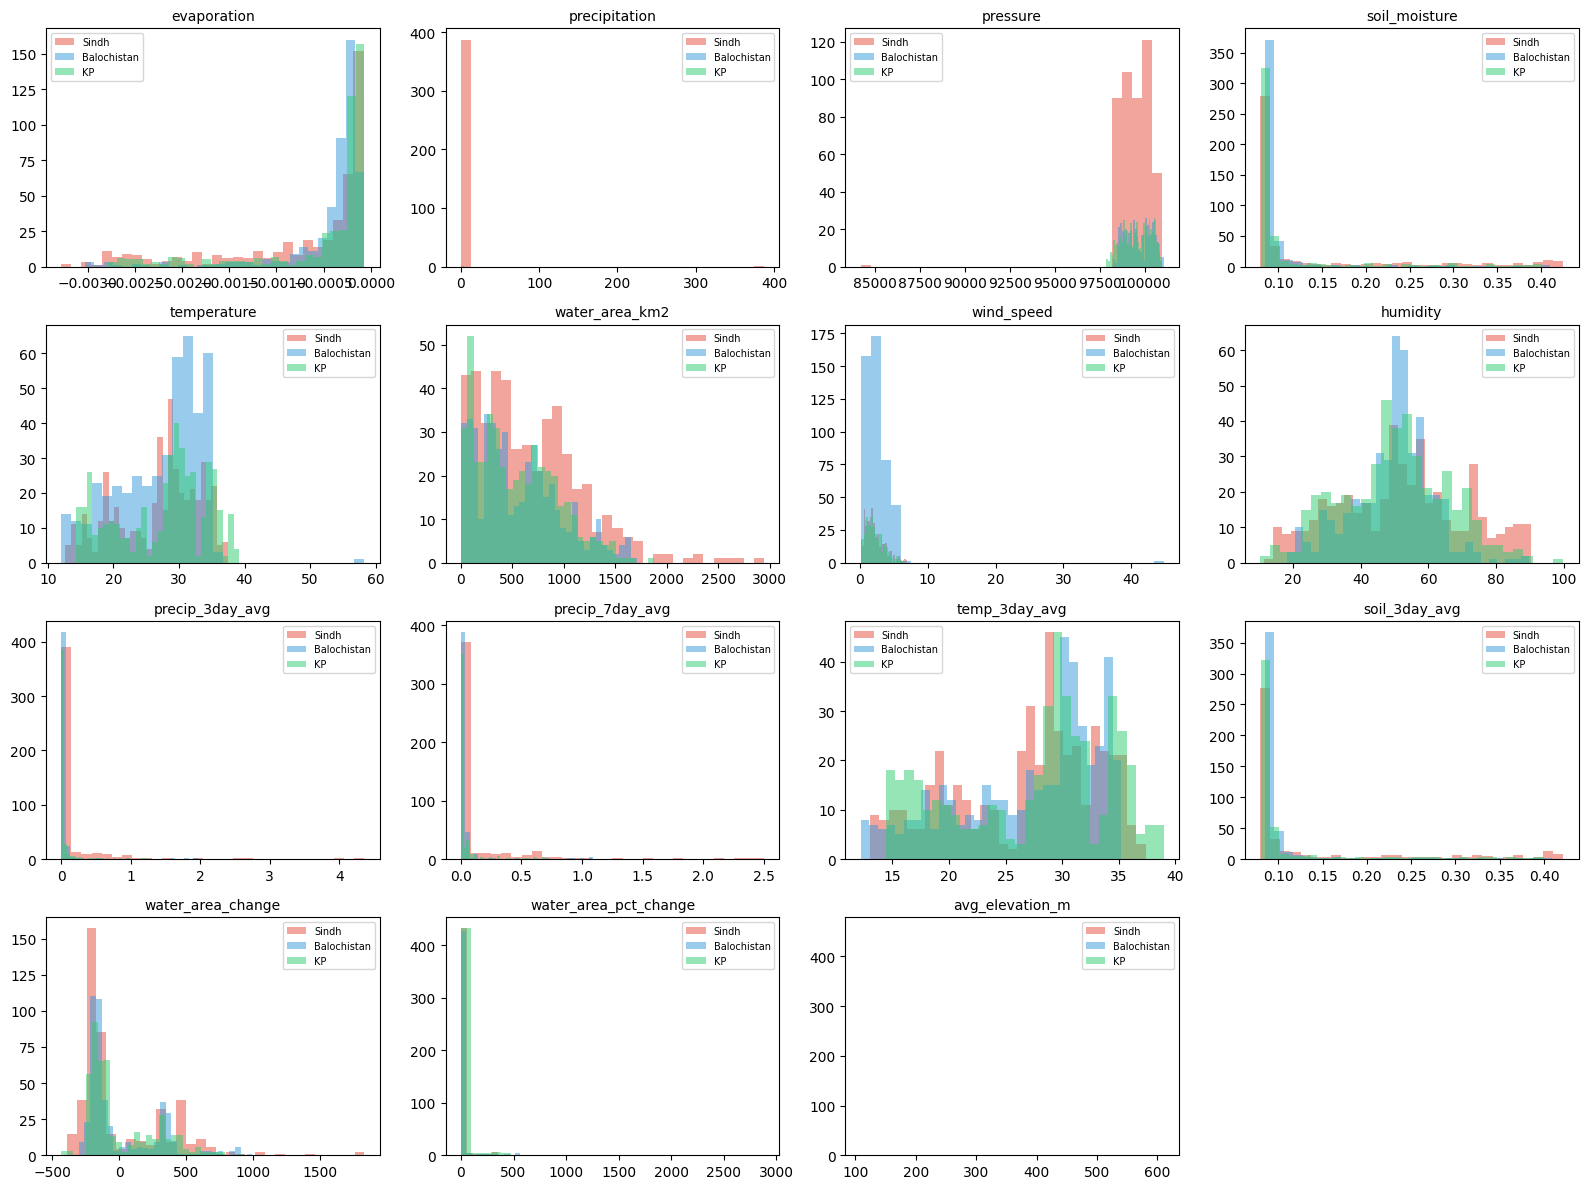

In [21]:
section("PHASE 3 — Feature distributions per district")

exclude_for_dist = ["flood_event", "year", "month", "day_of_year",
                    "is_monsoon", "is_missing_precipitation"]
numeric_features = [c for c in df.select_dtypes(include=np.number).columns
                    if c not in exclude_for_dist]
print(f"Plotting distributions for {len(numeric_features)} numeric features, faceted by district.")

n_cols = 4
n_rows = (len(numeric_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()
for i, feat in enumerate(numeric_features):
    ax = axes[i]
    for d in DISTRICTS:
        data = df[df["district"] == d][feat].dropna()
        ax.hist(data, bins=30, alpha=0.5, label=d.replace("_District", ""),
                color=DISTRICT_COLORS[d])
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=7)
for j in range(len(numeric_features), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/03_feature_distributions_per_district.png", dpi=80)

print("\nSkewness per feature (>1 = strongly skewed; trees are fine, linear models aren't):")
print(df[numeric_features].skew().sort_values(ascending=False).round(2).to_string())

In [22]:
section("PHASE 4 — Feature-target relationships")

correlations = {}
for feat in numeric_features:
    valid = df[[feat, "flood_event"]].dropna()
    if len(valid) > 10:
        r, p = stats.pointbiserialr(valid[feat], valid["flood_event"])
        correlations[feat] = (r, p)

corr_df = pd.DataFrame(correlations).T
corr_df.columns = ["correlation", "p_value"]
corr_df["abs_corr"] = corr_df["correlation"].abs()
corr_df = corr_df.sort_values("abs_corr", ascending=False)
print("Numeric features ranked by |correlation| with flood_event:")
print(corr_df[["correlation", "p_value"]].round(4).to_string())


PHASE 4 — Feature-target relationships
Numeric features ranked by |correlation| with flood_event:
                       correlation  p_value
water_area_km2              0.8126   0.0000
water_area_change           0.1798   0.0000
pressure                   -0.1273   0.0000
water_area_pct_change      -0.1156   0.0000
temperature                 0.1120   0.0000
temp_3day_avg               0.1112   0.0000
wind_speed                  0.1014   0.0002
avg_elevation_m            -0.0943   0.0005
soil_3day_avg               0.0587   0.0301
soil_moisture               0.0504   0.0627
evaporation                -0.0470   0.0824
humidity                   -0.0243   0.3691
precip_7day_avg             0.0200   0.4594
precipitation              -0.0193   0.5106
precip_3day_avg             0.0106   0.6969


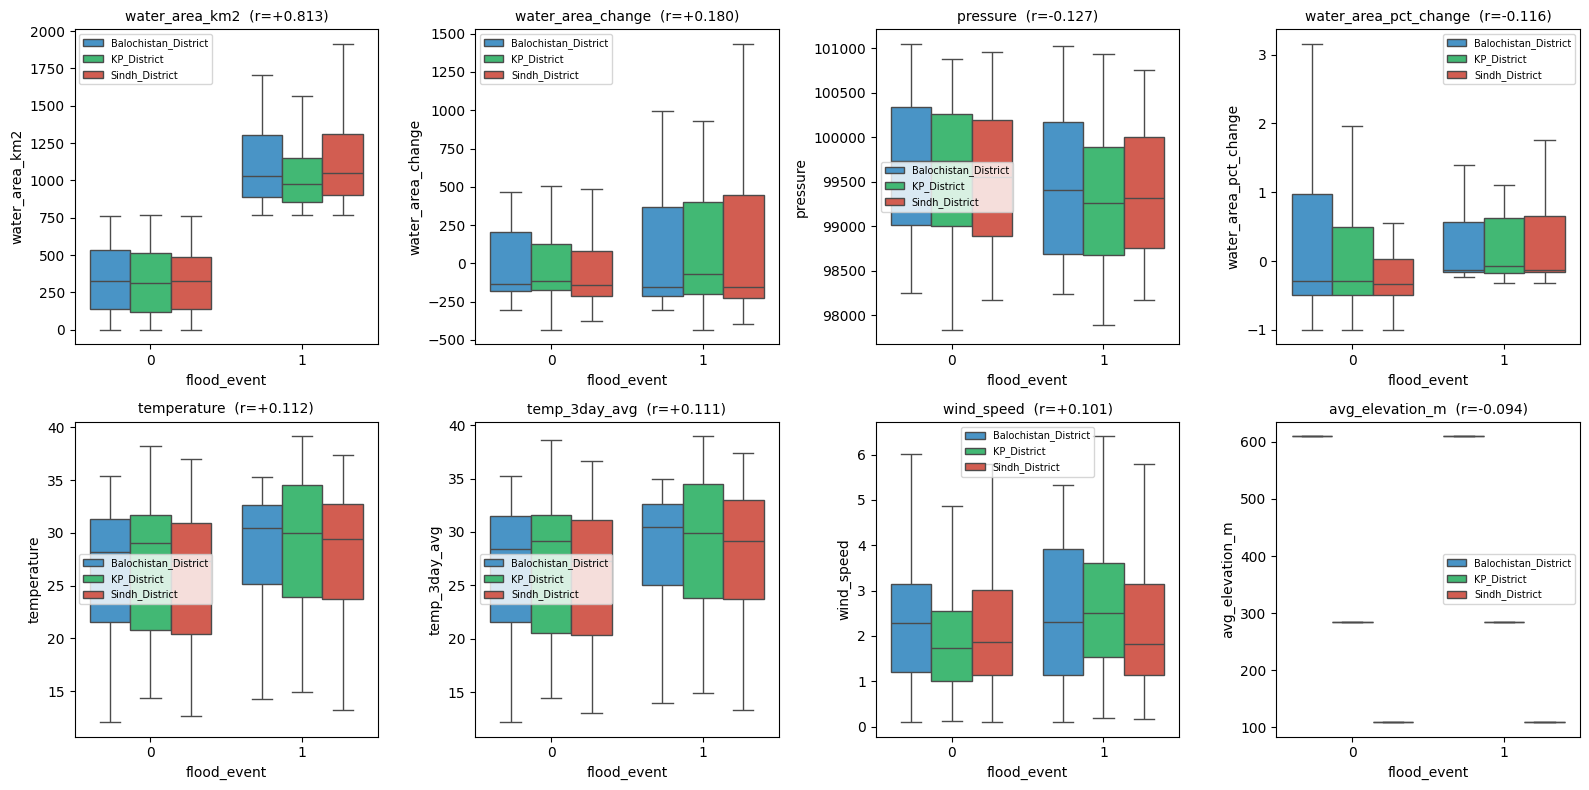

In [23]:
top_features = corr_df.head(8).index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, feat in zip(axes.flatten(), top_features):
    sns.boxplot(data=df, x="flood_event", y=feat, hue="district", ax=ax,
                palette=DISTRICT_COLORS, showfliers=False)
    r = correlations[feat][0]
    ax.set_title(f"{feat}  (r={r:+.3f})", fontsize=10)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/04a_top_features_boxplot.png", dpi=80)

In [24]:
print("\nBinary features — flood rate per category:")
binary_features = ["is_monsoon", "is_missing_precipitation"]
for feat in binary_features:
    rates = df.groupby(feat)["flood_event"].agg(["mean", "count"])
    print(f"\n{feat}:")
    print(rates.round(3).to_string())


Binary features — flood rate per category:

is_monsoon:
             mean  count
is_monsoon              
0           0.289    909
1           0.393    456

is_missing_precipitation:
                           mean  count
is_missing_precipitation              
0                         0.327   1160
1                         0.307    205



PHASE 5 — Precipitation / rolling-average investigation

3-day rolling avg comparison:
  Correlation (provided vs our recompute):  +0.0211
  Rows matching within 0.001:               1112/1360 (81.8%)
  Mean absolute difference:                  0.390

7-day rolling avg comparison:
  Correlation (provided vs our recompute):  +0.0236
  Rows matching within 0.001:               974/1364 (71.4%)
  Mean absolute difference:                  0.387


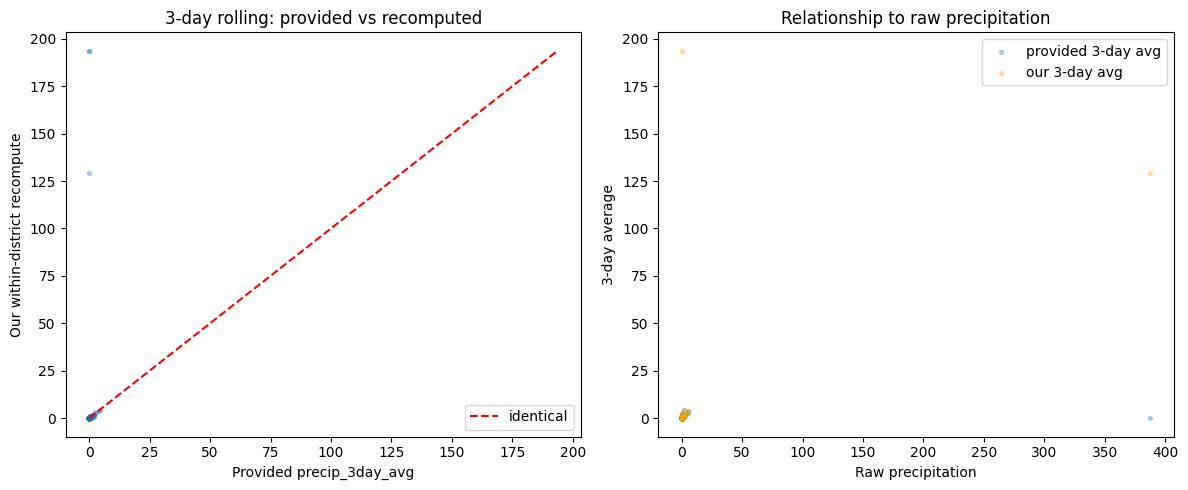

In [25]:
section("PHASE 5 — Precipitation / rolling-average investigation")

# Recompute rolling averages within district, sorted by date
df_sorted = df.sort_values(["district", "date"]).reset_index(drop=True)
df_sorted["my_precip_3day"] = (df_sorted.groupby("district")["precipitation"]
                                         .transform(lambda x: x.rolling(3, min_periods=1).mean()))
df_sorted["my_precip_7day"] = (df_sorted.groupby("district")["precipitation"]
                                         .transform(lambda x: x.rolling(7, min_periods=1).mean()))

# Compare
for window, provided_col, my_col in [("3-day", "precip_3day_avg", "my_precip_3day"),
                                       ("7-day", "precip_7day_avg", "my_precip_7day")]:
    valid = df_sorted[[provided_col, my_col]].dropna()
    if len(valid) > 0:
        r = valid[provided_col].corr(valid[my_col])
        match = (np.isclose(valid[provided_col], valid[my_col], atol=0.001)).sum()
        n_valid = len(valid)
        mean_abs_diff = (valid[provided_col] - valid[my_col]).abs().mean()
        print(f"\n{window} rolling avg comparison:")
        print(f"  Correlation (provided vs our recompute):  {r:+.4f}")
        print(f"  Rows matching within 0.001:               {match}/{n_valid} ({100*match/n_valid:.1f}%)")
        print(f"  Mean absolute difference:                  {mean_abs_diff:.3f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(df_sorted["precip_3day_avg"], df_sorted["my_precip_3day"], alpha=0.3, s=8)
mx = max(df_sorted["precip_3day_avg"].max(), df_sorted["my_precip_3day"].max())
axes[0].plot([0, mx], [0, mx], "r--", label="identical")
axes[0].set_xlabel("Provided precip_3day_avg")
axes[0].set_ylabel("Our within-district recompute")
axes[0].set_title("3-day rolling: provided vs recomputed")
axes[0].legend()

axes[1].scatter(df_sorted["precipitation"], df_sorted["precip_3day_avg"],
                alpha=0.3, s=8, label="provided 3-day avg")
axes[1].scatter(df_sorted["precipitation"], df_sorted["my_precip_3day"],
                alpha=0.3, s=8, color="orange", label="our 3-day avg")
axes[1].set_xlabel("Raw precipitation")
axes[1].set_ylabel("3-day average")
axes[1].set_title("Relationship to raw precipitation")
axes[1].legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/05_rolling_avg_investigation.png", dpi=80)

In [26]:
section("PHASE 6 — Train/validation chronological split check")

split_date = pd.Timestamp("2024-01-01")
train_period = df[df["date"] <  split_date]
val_period   = df[df["date"] >= split_date]

print(f"Proposed split: train < 2024-01-01,  val >= 2024-01-01")
print(f"  Train: {len(train_period)} rows  ({train_period['date'].min().date()} to {train_period['date'].max().date()})")
print(f"  Val:   {len(val_period)} rows  ({val_period['date'].min().date()} to {val_period['date'].max().date()})")
print(f"  Train flood rate: {train_period['flood_event'].mean():.3f}")
print(f"  Val flood rate:   {val_period['flood_event'].mean():.3f}")

print("\nKS test per feature (p < 0.01 = significant drift between train and val):")
ks_results = []
for feat in numeric_features:
    tr = train_period[feat].dropna()
    vl = val_period[feat].dropna()
    if len(tr) > 10 and len(vl) > 10:
        stat, p = stats.ks_2samp(tr, vl)
        ks_results.append({"feature": feat, "ks_stat": stat, "p_value": p,
                          "drift": "DRIFT" if p < 0.01 else ""})

ks_df = pd.DataFrame(ks_results).sort_values("ks_stat", ascending=False)
print(ks_df.to_string(index=False))

print("\nDistrict distribution per period:")
print(pd.crosstab(df["district"], df["date"] >= split_date,
                  normalize="columns").round(3).to_string())


PHASE 6 — Train/validation chronological split check
Proposed split: train < 2024-01-01,  val >= 2024-01-01
  Train: 911 rows  (2022-01-01 to 2023-12-31)
  Val:   454 rows  (2024-01-01 to 2024-12-30)
  Train flood rate: 0.341
  Val flood rate:   0.289

KS test per feature (p < 0.01 = significant drift between train and val):
              feature  ks_stat      p_value drift
      avg_elevation_m 0.500549 1.164347e-69 DRIFT
          evaporation 0.269731 7.073101e-20 DRIFT
        soil_moisture 0.183013 2.392333e-09 DRIFT
        soil_3day_avg 0.181901 3.074519e-09 DRIFT
    water_area_change 0.138916 1.446008e-05 DRIFT
        temp_3day_avg 0.128989 7.348445e-05 DRIFT
          temperature 0.122475 1.998227e-04 DRIFT
      precip_7day_avg 0.101803 3.404550e-03 DRIFT
      precip_3day_avg 0.085507 2.208779e-02      
             pressure 0.073886 6.843821e-02      
           wind_speed 0.073388 7.178494e-02      
             humidity 0.071783 8.258373e-02      
       water_area_km2 

In [27]:
section("PHASE 7 — Updated correlation / redundancy analysis")

features_for_corr = [c for c in df.select_dtypes(include=np.number).columns
                     if c not in ["flood_event"]]
clean_data = df[features_for_corr].replace([np.inf, -np.inf], np.nan).copy()
scaler = StandardScaler()
scaled = scaler.fit_transform(clean_data.fillna(0))
features_t = pd.DataFrame(scaled, columns=features_for_corr).T

Z = linkage(features_t, method="ward")
plt.figure(figsize=(14, 6))
dend = dendrogram(Z, labels=features_t.index.tolist(), leaf_rotation=90, leaf_font_size=10)
plt.title("Feature dendrogram on cleaned data (StandardScaled, Ward linkage)")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/07a_dendrogram_clean.png", dpi=80)
plt.close()

plt.figure(figsize=(12, 10))
corr = clean_data[dend["ivl"]].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.7})
plt.title("Correlation heatmap, dendrogram-ordered (cleaned data)")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/07b_correlation_heatmap_clean.png", dpi=80)
plt.close()

print("\nFeature pairs with |correlation| > 0.8 (potential redundancy):")
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.8:
            high_corr.append((corr.columns[i], corr.columns[j], r))
high_corr.sort(key=lambda x: -abs(x[2]))
for a, b, r in high_corr:
    print(f"  {a} <-> {b}: r = {r:+.3f}")


PHASE 7 — Updated correlation / redundancy analysis

Feature pairs with |correlation| > 0.8 (potential redundancy):
  day_of_year <-> month: r = +0.996
  temperature <-> temp_3day_avg: r = +0.990
  soil_moisture <-> soil_3day_avg: r = +0.988
  precip_3day_avg <-> precip_7day_avg: r = +0.838


In [28]:
section("EDA DELIVERABLES — for Step 4 feature engineering")

print("\nTop 5 predictive features (by |correlation|):")
print(corr_df.head(5)[["correlation", "p_value"]].round(4).to_string())

print("\nWeakest 5 features (candidates to drop or de-prioritize):")
print(corr_df.tail(5)[["correlation", "p_value"]].round(4).to_string())

print(f"\nPlots saved to: {PLOTS_DIR}/")
for p in sorted(os.listdir(PLOTS_DIR)):
    print(f"  - {p}")



EDA DELIVERABLES — for Step 4 feature engineering

Top 5 predictive features (by |correlation|):
                       correlation  p_value
water_area_km2              0.8126      0.0
water_area_change           0.1798      0.0
pressure                   -0.1273      0.0
water_area_pct_change      -0.1156      0.0
temperature                 0.1120      0.0

Weakest 5 features (candidates to drop or de-prioritize):
                 correlation  p_value
evaporation          -0.0470   0.0824
humidity             -0.0243   0.3691
precip_7day_avg       0.0200   0.4594
precipitation        -0.0193   0.5106
precip_3day_avg       0.0106   0.6969

Plots saved to: eda_plots/
  - 01a_flood_timeseries.png
  - 01b_flood_rate_month_district.png
  - 03_feature_distributions_per_district.png
  - 04a_top_features_boxplot.png
  - 05_rolling_avg_investigation.png
  - 07a_dendrogram_clean.png
  - 07b_correlation_heatmap_clean.png
